In [1]:
import pandas as pd
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Month Number
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,Dec,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,Dec,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,Dec,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,Dec,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,Dec,12


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397924 entries, 0 to 397923
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     397924 non-null  int64         
 1   StockCode     397924 non-null  object        
 2   Description   397924 non-null  object        
 3   Quantity      397924 non-null  int64         
 4   InvoiceDate   397924 non-null  datetime64[ns]
 5   UnitPrice     397924 non-null  float64       
 6   CustomerID    397924 non-null  int64         
 7   Country       397924 non-null  object        
 8   TotalPrice    397924 non-null  float64       
 9   Year          397924 non-null  int64         
 10  Month         397924 non-null  object        
 11  Month Number  397924 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(5), object(4)
memory usage: 36.4+ MB


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,Month Number
count,397924.000000,397924.000000,397924,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000
mean,560617.126645,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,22.394749,2010.934259,7.612537
min,536365.000000,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000,2010.000000,1.000000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000,2011.000000,5.000000
50%,561893.000000,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000,2011.000000,8.000000
75%,572090.000000,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000,2011.000000,11.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000
std,13106.167695,180.420210,NaN,22.096788,1713.169877,309.055588,0.247829,3.416527


In [3]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df.dropna(subset=['CustomerID'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.strftime('%b')

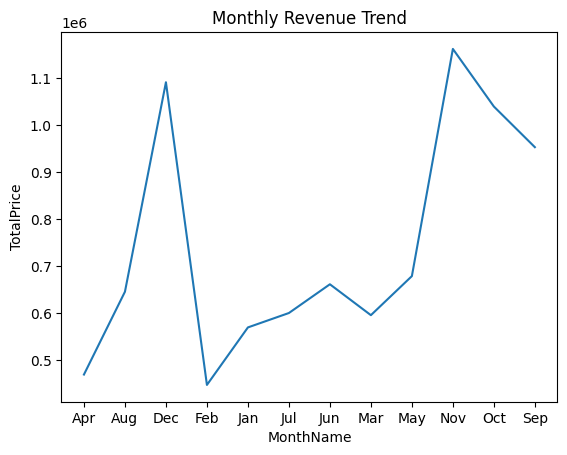

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales = df.groupby('MonthName')['TotalPrice'].sum().reset_index()

plt.figure()
sns.lineplot(data=monthly_sales, x='MonthName', y='TotalPrice')
plt.title("Monthly Revenue Trend")
plt.show()

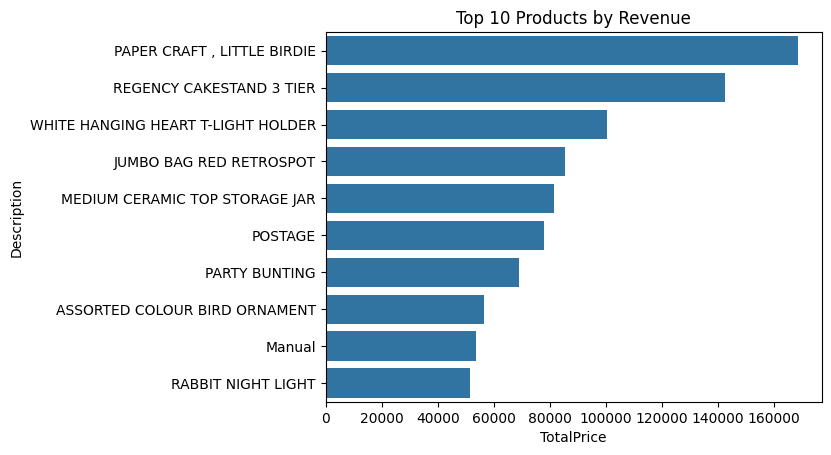

In [6]:
top_products = df.groupby('Description')['TotalPrice'].sum().nlargest(10).reset_index()

plt.figure()
sns.barplot(data=top_products, x='TotalPrice', y='Description')
plt.title("Top 10 Products by Revenue")
plt.show()

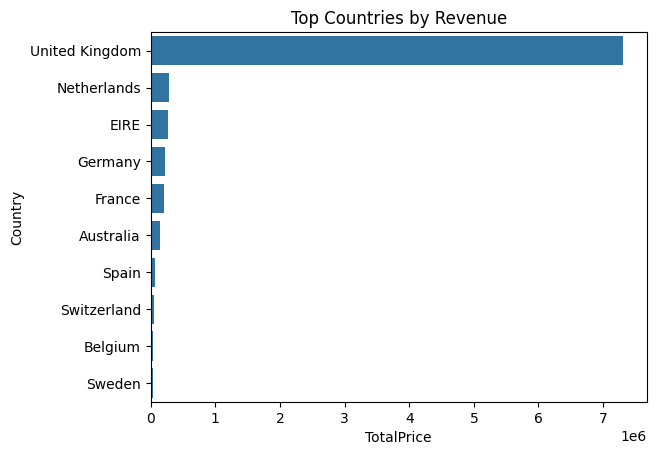

In [7]:
country_sales = df.groupby('Country')['TotalPrice'].sum().nlargest(10).reset_index()

plt.figure()
sns.barplot(data=country_sales, x='TotalPrice', y='Country')
plt.title("Top Countries by Revenue")
plt.show()

->Revenue peaks in November and December, indicating seasonal demand.

->United Kingdom dominates sales, contributing majority revenue.

-> Top products contribute disproportionately to total revenue.